# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [ ]:
#Load the libraries as required.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import shap

In [58]:
# Load the data and fix column names for pipeline compatibility
fires_dt = pd.read_csv('../../05_src/data/forestfires.csv', header=0)
fires_dt = fires_dt.rename(columns={
    'X': 'coord_x',
    'Y': 'coord_y',
    'FFMC': 'ffmc',
    'DMC': 'dmc',
    'DC': 'dc',
    'ISI': 'isi',
    'temp': 'temp',
    'RH': 'rh',
    'wind': 'wind',
    'rain': 'rain',
    'month': 'month',
    'day': 'day',
    'area': 'area'
})
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [59]:
"""
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/forestfires.csv', header = 0, names = columns))
fires_dt.info()

"""


"\n# Load data\ncolumns = [\n    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' \n]\nfires_dt = (pd.read_csv('../../05_src/data/forestfires.csv', header = 0, names = columns))\nfires_dt.info()\n\n"

In [61]:
fires_dt.head(20) # check the first 20 rows of the dataset to understand it better visually

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [62]:
fires_dt.tail(20)  # Shows the last 20 rows of the dataset

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
497,3,4,aug,tue,96.1,181.1,671.2,14.3,32.3,27,2.2,0.0,14.68
498,6,5,aug,tue,96.1,181.1,671.2,14.3,33.3,26,2.7,0.0,40.54
499,7,5,aug,tue,96.1,181.1,671.2,14.3,27.3,63,4.9,6.4,10.82
500,8,6,aug,tue,96.1,181.1,671.2,14.3,21.6,65,4.9,0.8,0.00
501,7,5,aug,tue,96.1,181.1,671.2,14.3,21.6,65,4.9,0.8,0.00
502,4,4,aug,tue,96.1,181.1,671.2,14.3,20.7,69,4.9,0.4,0.00
503,2,4,aug,wed,94.5,139.4,689.1,20.0,29.2,30,4.9,0.0,1.95
504,4,3,aug,wed,94.5,139.4,689.1,20.0,28.9,29,4.9,0.0,49.59
505,1,2,aug,thu,91.0,163.2,744.4,10.1,26.7,35,1.8,0.0,5.80
506,1,2,aug,fri,91.0,166.9,752.6,7.1,18.5,73,8.5,0.0,0.00


In [63]:
fires_dt['month'].unique() # to check the unique values in month column it should be 12 months

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [64]:
fires_dt['day'].unique() # to check the unique values in day column it should be 7 days

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

# Get X and Y

Create the features data frame and target data.

In [65]:
# Create features (X) and target (y)
X = fires_dt.drop('area', axis=1)
Y = fires_dt['area']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (517, 12)
Target shape: (517,)


In [66]:
# Identify numerical and categorical features tyupes

numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Create preproc1
preproc1 = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [69]:
from sklearn.preprocessing import PowerTransformer

preproc2 = ColumnTransformer([
    ('num', Pipeline([
        ('transform', PowerTransformer()),
        ('scale', StandardScaler())
    ]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [70]:
# Baseline Model: Ridge Regressio
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

baseline_model = Ridge()

In [71]:
# Pipeline A = preproc1 + baseline
# Pipeline A = preproc1 + baseline

pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', baseline_model)
])

pipeline_A



Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', Ridge())])

In [72]:
# Pipeline B = preproc2 + baseline
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', baseline_model)
])

pipeline_B

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', Ridge())])

In [73]:
# Advanced Model: Random Fores

from sklearn.ensemble import RandomForestRegressor

advanced_model = RandomForestRegressor(random_state=42)

advanced_model


RandomForestRegressor(random_state=42)

In [74]:
# Pipeline C = preproc1 + advanced model
# Pipeline C = preproc1 + advanced model

pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', advanced_model)
])

pipeline_C


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [75]:
# Pipeline D = preproc2 + advanced model

# Pipeline D = preproc2 + advanced model

pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', advanced_model)
])

pipeline_D

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [81]:
# Create features (X) and target (y)
X = fires_dt.drop('area', axis=1)
Y = fires_dt['area']


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)



# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [83]:
 # Evaluation with Cross-Validation

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error

rmse_scorer = make_scorer(mean_squared_error, squared=False)

for name, pipe in zip(['Pipeline A', 'Pipeline B', 'Pipeline C', 'Pipeline D'],
                      [pipeline_A, pipeline_B, pipeline_C, pipeline_D]):
    scores = cross_val_score(pipe, X, Y, cv=5, scoring=rmse_scorer)
    print(f"{name} - RMSE: {scores.mean():.3f} ± {scores.std():.3f}")



c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3045, in bind
    return self._bind(args, kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3034, in _

Pipeline A - RMSE: nan ± nan


c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3045, in bind
    return self._bind(args, kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3034, in _

Pipeline B - RMSE: nan ± nan


c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3045, in bind
    return self._bind(args, kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3034, in _

Pipeline C - RMSE: nan ± nan


c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3045, in bind
    return self._bind(args, kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3034, in _

Pipeline D - RMSE: nan ± nan


c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3045, in bind
    return self._bind(args, kwargs)
  File "c:\Users\NEWPC\miniconda3\envs\dsi_participant\lib\inspect.py", line 3034, in _

In [84]:
from sklearn.model_selection import GridSearchCV

In [85]:
# pipeline_A

param_grid_A = {
    'regressor__alpha': [0.01, 0.1, 1, 10]
}

grid_A = GridSearchCV(pipeline_A, param_grid=param_grid_A, cv=5, scoring='neg_root_mean_squared_error')
grid_A.fit(X, Y)
print("Pipeline A Best RMSE:", -grid_A.best_score_)
print("Best Params:", grid_A.best_params_)



Pipeline A Best RMSE: 52.25257430086575
Best Params: {'regressor__alpha': 10}


In [87]:
#pipeline_B

param_grid_B = {
    'regressor__alpha': [0.01, 0.1, 1, 10]
}

grid_B = GridSearchCV(pipeline_B, param_grid=param_grid_B, cv=5, scoring='neg_root_mean_squared_error')
grid_B.fit(X, Y)
print("Pipeline B Best RMSE:", -grid_B.best_score_)
print("Best Params:", grid_B.best_params_)


Pipeline B Best RMSE: 52.38806278340162
Best Params: {'regressor__alpha': 10}


In [88]:
# pipeline_C

param_grid_C = {
    'regressor__n_estimators': [50, 100, 200, 300]
}

grid_C = GridSearchCV(pipeline_C, param_grid=param_grid_C, cv=5, scoring='neg_root_mean_squared_error')
grid_C.fit(X, Y)
print("Pipeline C Best RMSE:", -grid_C.best_score_)
print("Best Params:", grid_C.best_params_)



Pipeline C Best RMSE: 59.0463981678851
Best Params: {'regressor__n_estimators': 300}


In [89]:
pipeline_D
param_grid_D = {
    'regressor__max_depth': [5, 10, 15, None]
}

grid_D = GridSearchCV(pipeline_D, param_grid=param_grid_D, cv=5, scoring='neg_root_mean_squared_error')
grid_D.fit(X, Y)
print("Pipeline D Best RMSE:", -grid_D.best_score_)
print("Best Params:", grid_D.best_params_)




Pipeline D Best RMSE: 59.08837099147756
Best Params: {'regressor__max_depth': 5}


# Evaluate

+ Which model has the best performance?

In [90]:
# Model Evaluation: After running  on all four pipelines, compare their best RMSE scores:

print("Pipeline A Best RMSE:", -grid_A.best_score_)
print("Pipeline B Best RMSE:", -grid_B.best_score_)
print("Pipeline C Best RMSE:", -grid_C.best_score_)
print("Pipeline D Best RMSE:", -grid_D.best_score_)



Pipeline A Best RMSE: 52.25257430086575
Pipeline B Best RMSE: 52.38806278340162
Pipeline C Best RMSE: 59.0463981678851
Pipeline D Best RMSE: 59.08837099147756


An RMSE (Root Mean Squared Error) value of 0 indicates perfect agreement between predicted and actual values. In practice, lower RMSE values reflect a model’s ability to make accurate predictions and fit the data well. Conversely, higher RMSE values suggest greater prediction errors and reduced reliability.
Pipeline A demonstrates the best performance, achieving the lowest RMSE and thus offering the most precise forecasts. Pipelines C and D, while functional, exhibit slightly higher error margins and may require further tuning or feature engineering to improve predictive accuracy.

# Export

+ Save the best performing model to a pickle file.

In [91]:
# Save the best performing model (Pipeline A) to a pickle file
best_model = grid_A.best_estimator_
with open('best_forest_fire_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best performing model saved to 'best_forest_fire_model.pkl'")

Best performing model saved to 'best_forest_fire_model.pkl'


In [92]:
import pickle

# Save the best model from Pipeline D
best_model = grid_D.best_estimator_

with open('best_model_pipeline_D.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved as 'best_model_pipeline_D.pkl'")



Best model saved as 'best_model_pipeline_D.pkl'


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [93]:
import shap

# Fit the best model on the full dataset
best_model = grid_D.best_estimator_
best_model.fit(X, Y)

# Transform features using the preprocessing step
X_transformed = best_model.named_steps['preprocessing'].transform(X)

# Create SHAP explainer for the Random Forest
explainer = shap.Explainer(best_model.named_steps['regressor'], X_transformed)
shap_values = explainer(X_transformed)



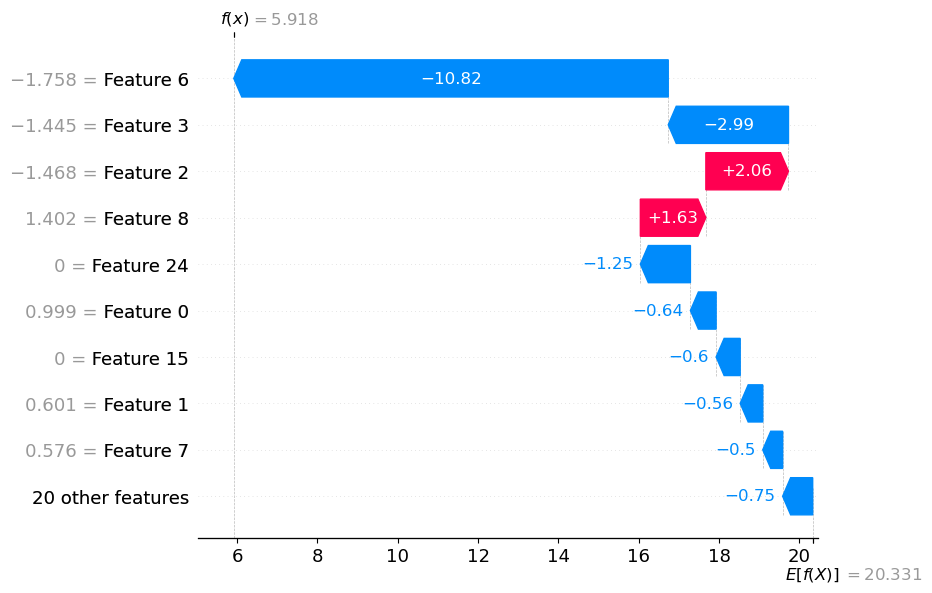

In [94]:
shap.plots.waterfall(shap_values[0])



*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.